From: https://towardsdatascience.com/markov-chain-analysis-and-simulation-using-python-4507cee0b06e

## Markov Chain Analysis and Simulation using Python

Solving real-world problems with probabilities

A Markov chain is a discrete-time stochastic process that progresses from one state to another with certain probabilities that can be represented by a graph and state transition matrix P as indicated below:

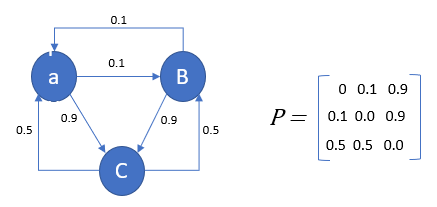

Such chains, if they are first-order Markov Chains, exhibit the Markov property, being that the next state is only dependent on the current state, and not how it got there:

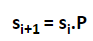

In this post we look at two separate concepts, the one being simulating from a Markov Chain, and the other calculating its stationary distribution. The stationary distribution is the fraction of time that the system spends in each state as the number of samples approaches infinity. If we have N states, the stationary distribution is a vector of length N, of which the values sum up to 1, since it’s a probability distribution.

We also look at two examples, a simple toy example, as well as a possible real-world scenario analysis problem.

## Calculating the Stationary Distribution

Note that in the first implementation below is not a simulation of the state transitions, just a calculation of the stationary distribution.

Let’s start with an iterative approach to calculating the distribution. What we are doing is raising the transition matrix to the power of the number of iterations:

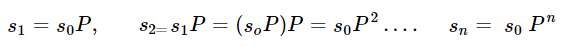

The stationary distribution is usually referred to as π.

So

1_zbWBjSC1Xba9zODUDMkftA.png

[[0.2 0.7 0.1]]
[[0.69 0.22 0.09]]
[[0.354 0.555 0.091]]
[[0.5885 0.3206 0.0909]]
[[0.42442 0.48467 0.09091]]
[[0.539269 0.369822 0.090909]]
[[0.4588754 0.4502155 0.0909091]]
[[0.51515085 0.39394006 0.09090909]]
[[0.47575804 0.43333287 0.09090909]]
[[0.50333301 0.4057579  0.09090909]]
[[0.48403053 0.42506038 0.09090909]]
[[0.49754226 0.41154864 0.09090909]]
[[0.48808405 0.42100686 0.09090909]]
[[0.4947048  0.41438611 0.09090909]]
[[0.49007028 0.41902063 0.09090909]]
[[0.49331444 0.41577647 0.09090909]]
[[0.49104353 0.41804738 0.09090909]]
[[0.49263317 0.41645774 0.09090909]]
[[0.49152042 0.41757049 0.09090909]]
[[0.49229934 0.41679157 0.09090909]]
[[0.4917541  0.41733681 0.09090909]]
[[0.49213577 0.41695514 0.09090909]]
[[0.4918686  0.41722231 0.09090909]]
[[0.49205562 0.41703529 0.09090909]]
[[0.4919247  0.41716621 0.09090909]]
[[0.49201634 0.41707457 0.09090909]]
[[0.4919522  0.41713871 0.09090909]]
[[0.4919971  0.41709381 0.09090909]]


/home/covino/miniconda3/lib/python3.9/site-packages/pandas/plotting/_matplotlib/core.py:512: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = self.plt.figure(figsize=self.figsize)


[[0.49196567 0.41712524 0.09090909]]
[[0.49198767 0.41710324 0.09090909]]
[[0.49197227 0.41711864 0.09090909]]
[[0.49198305 0.41710786 0.09090909]]
[[0.4919755  0.41711541 0.09090909]]
[[0.49198078 0.41711012 0.09090909]]
[[0.49197709 0.41711382 0.09090909]]
[[0.49197968 0.41711123 0.09090909]]
[[0.49197786 0.41711305 0.09090909]]
[[0.49197913 0.41711178 0.09090909]]
[[0.49197824 0.41711267 0.09090909]]
[[0.49197887 0.41711204 0.09090909]]
[[0.49197843 0.41711248 0.09090909]]
[[0.49197874 0.41711217 0.09090909]]
[[0.49197852 0.41711239 0.09090909]]
[[0.49197867 0.41711224 0.09090909]]
[[0.49197857 0.41711234 0.09090909]]
[[0.49197864 0.41711227 0.09090909]]
[[0.49197859 0.41711232 0.09090909]]
[[0.49197862 0.41711228 0.09090909]]
[[0.4919786  0.41711231 0.09090909]]
[[0.49197862 0.41711229 0.09090909]]


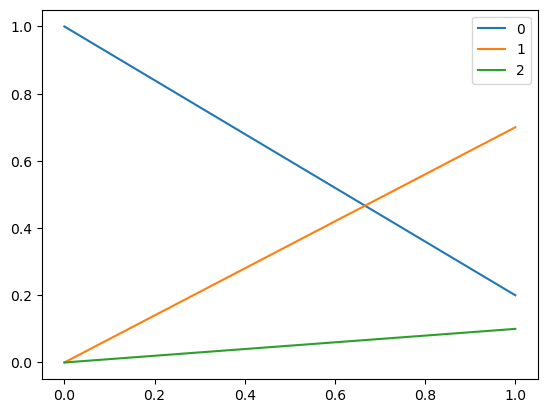

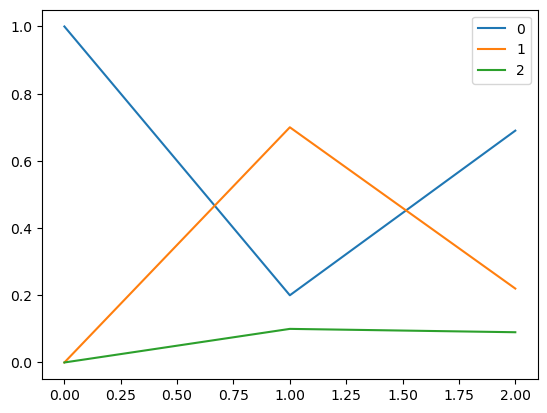

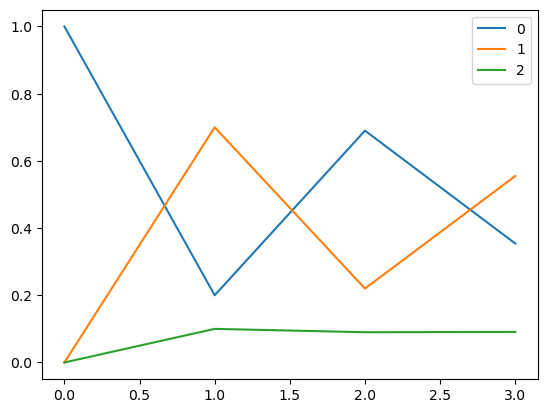

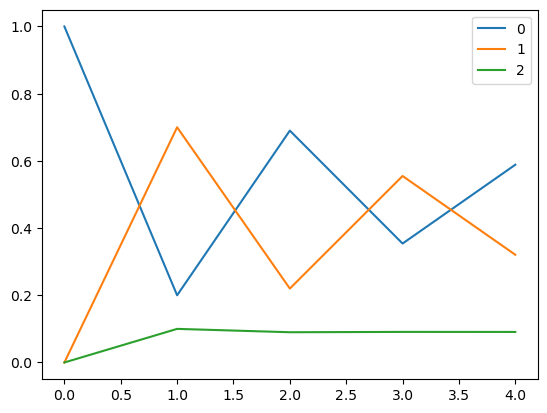

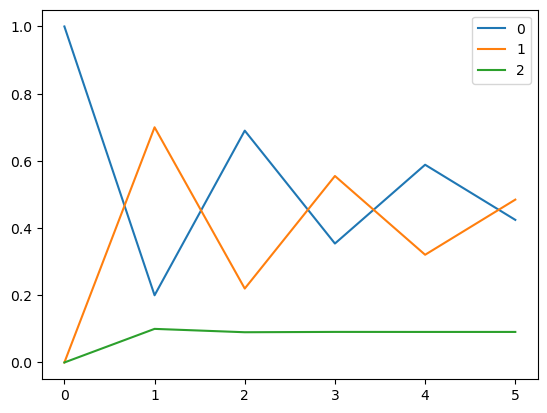

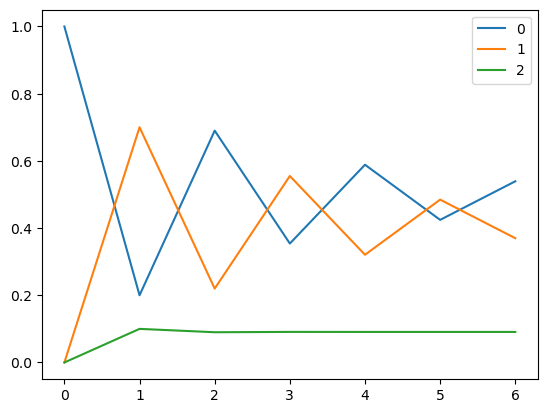

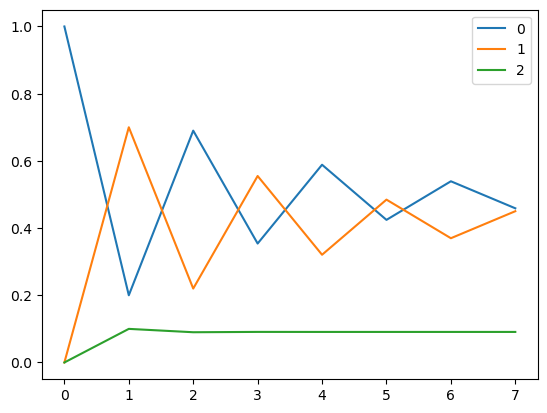

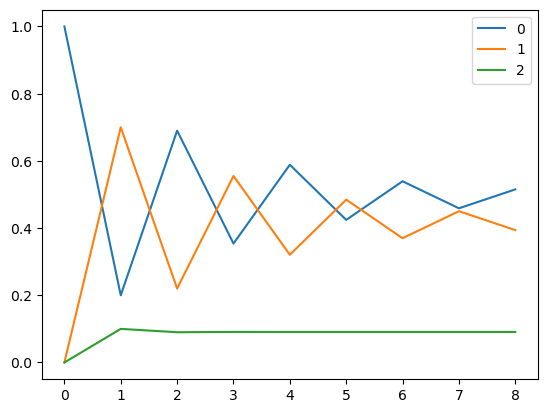

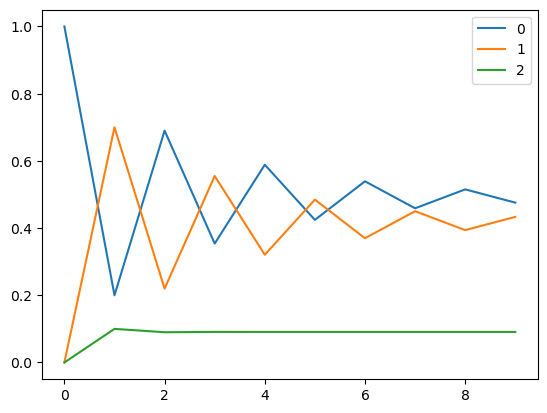

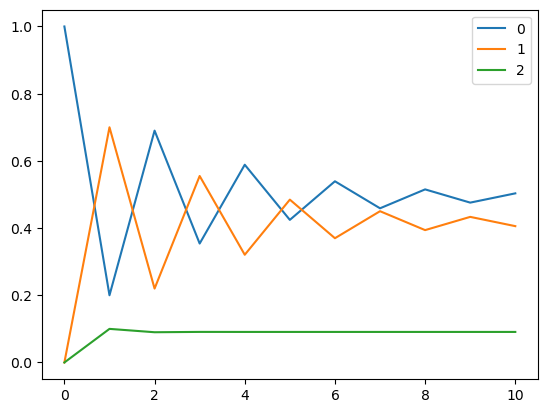

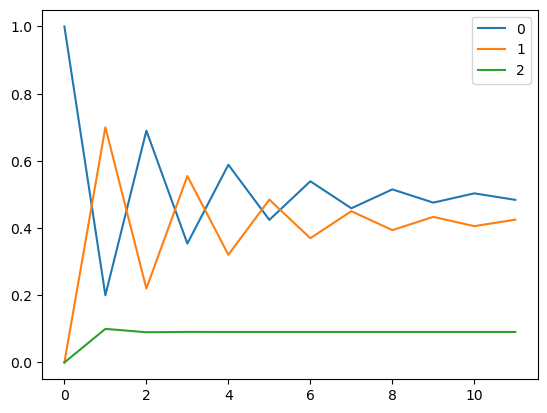

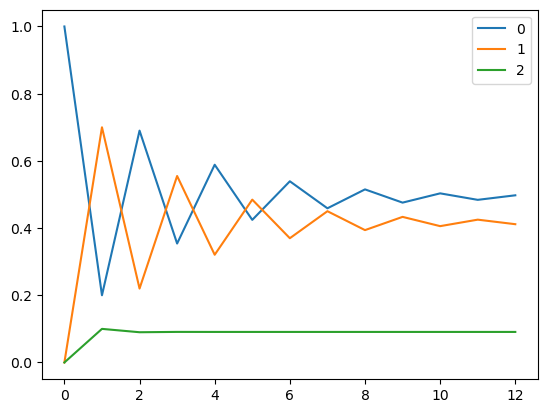

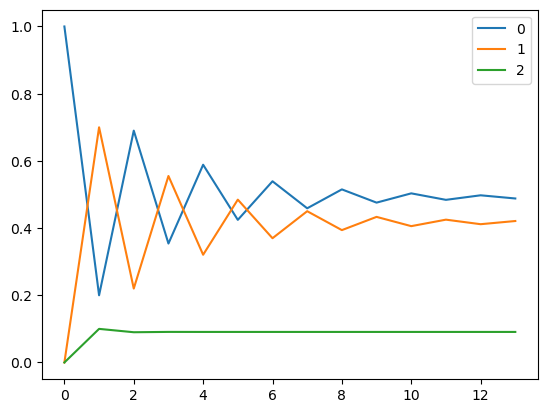

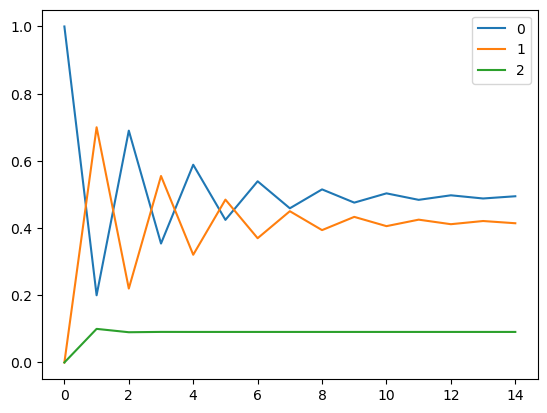

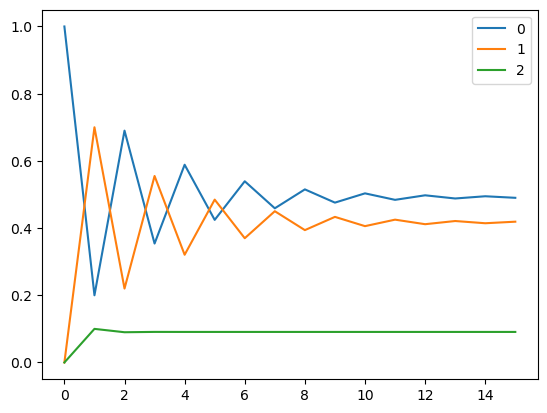

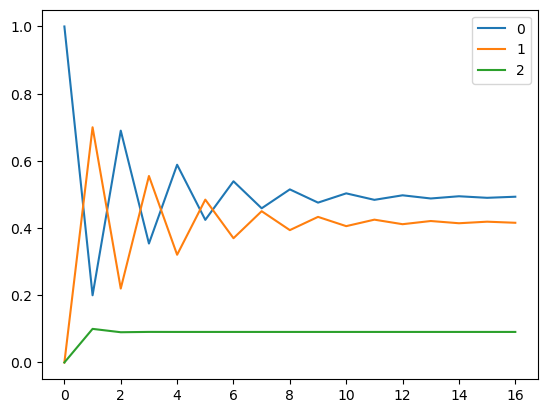

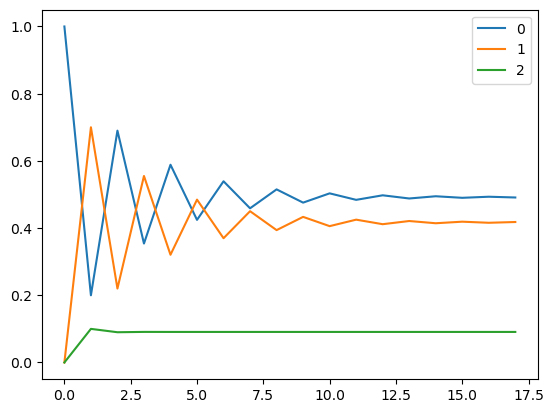

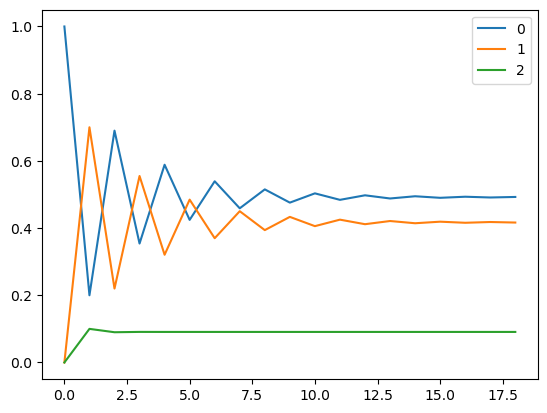

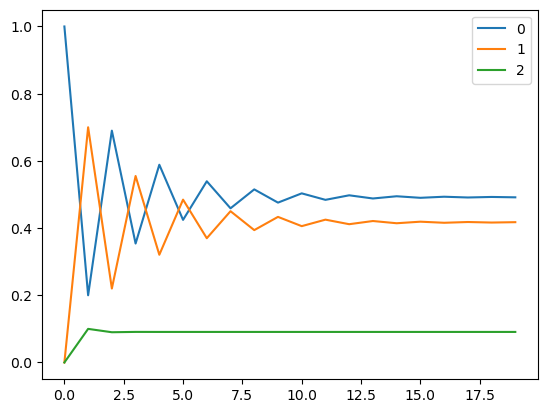

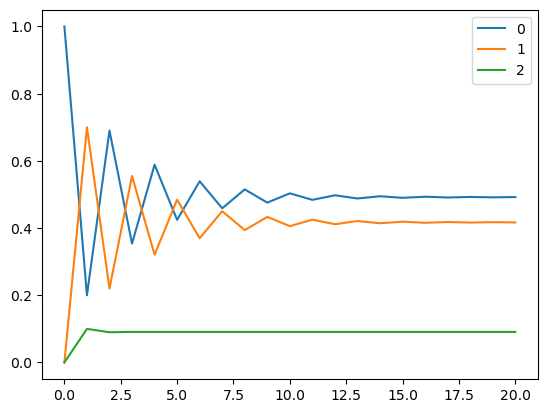

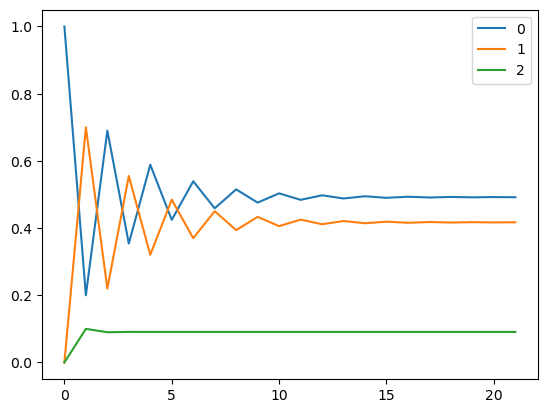

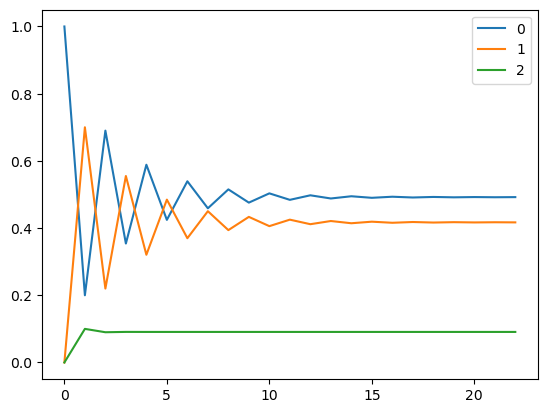

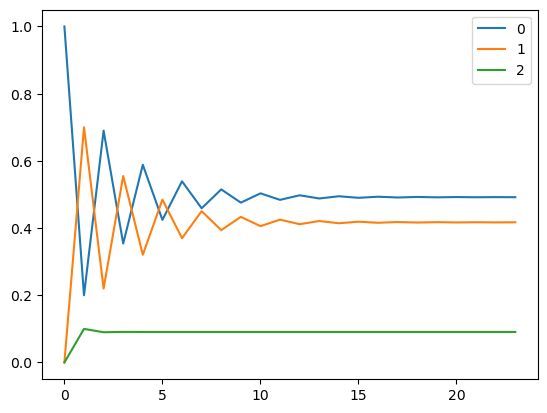

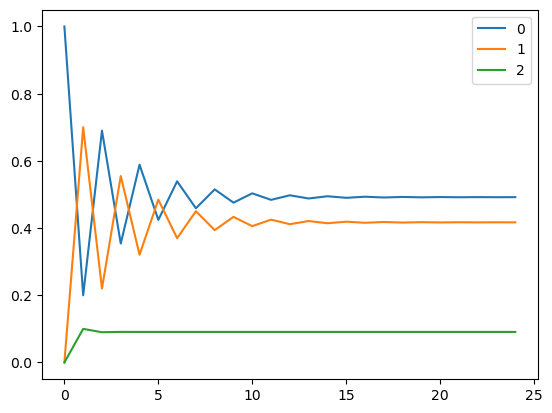

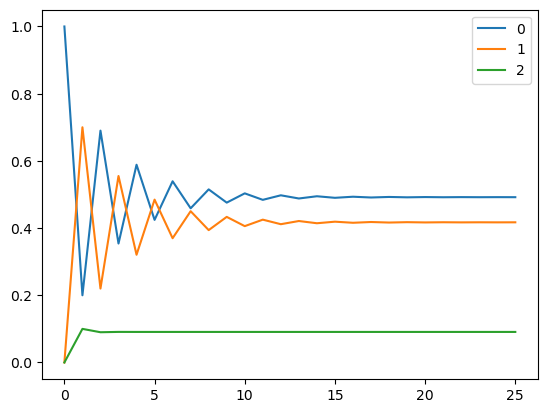

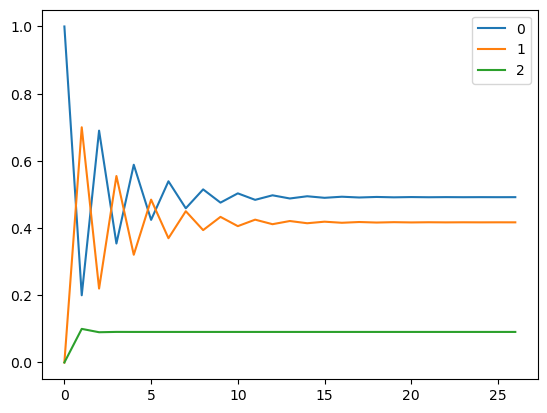

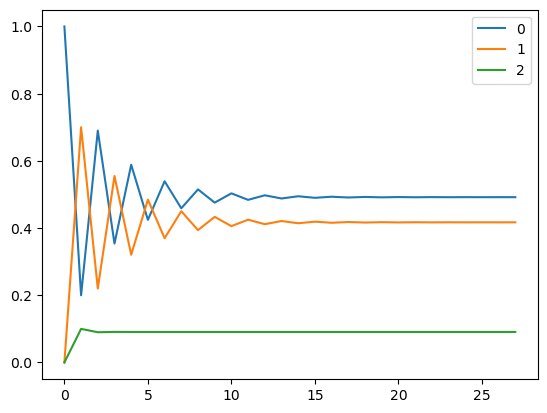

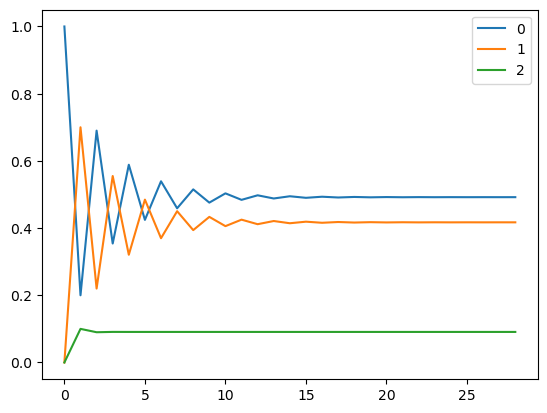

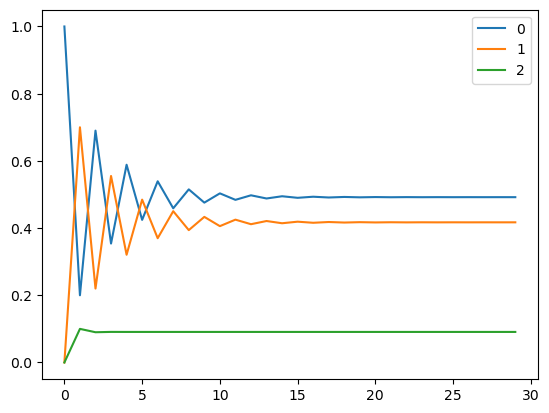

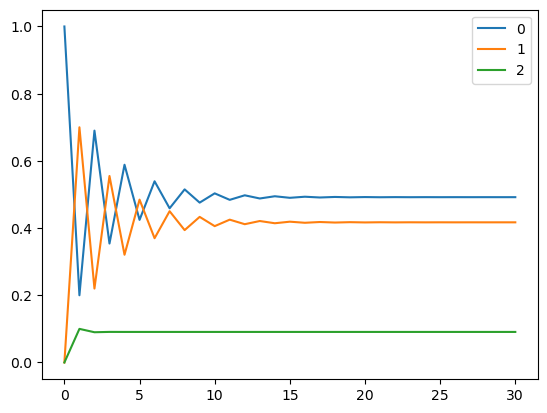

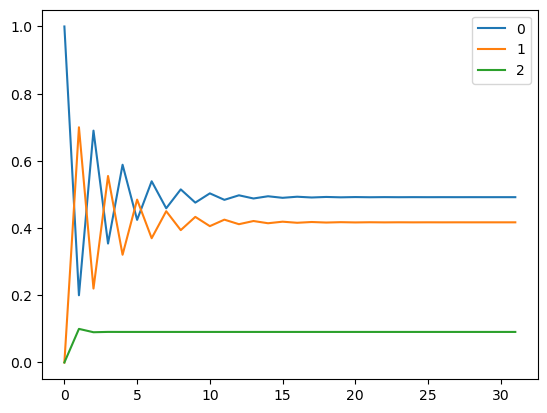

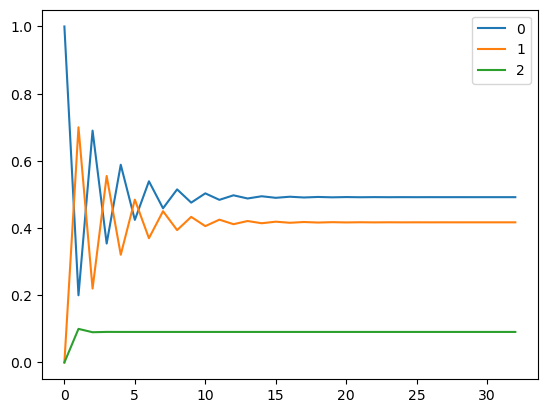

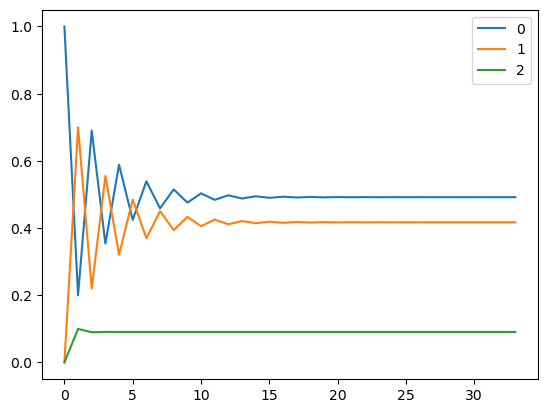

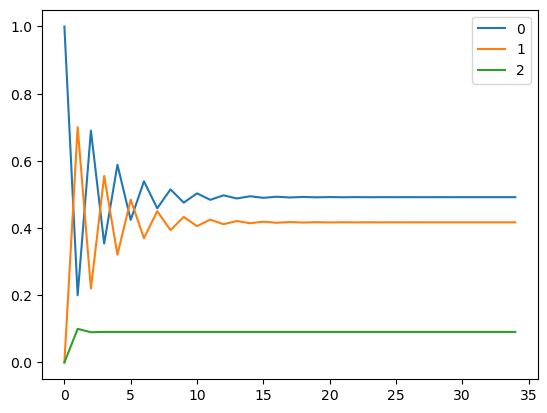

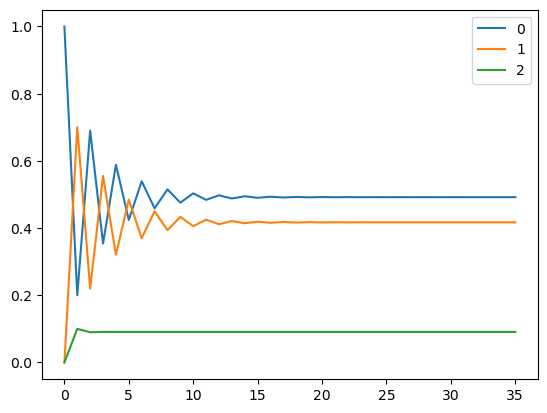

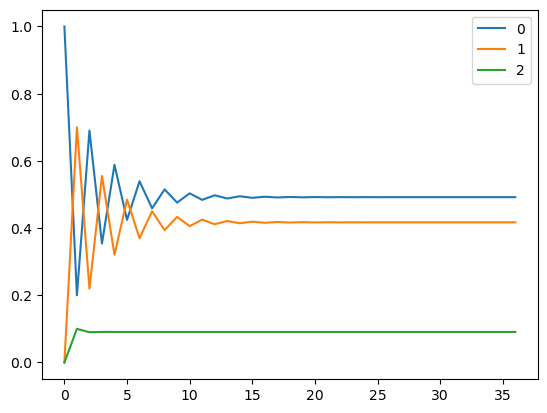

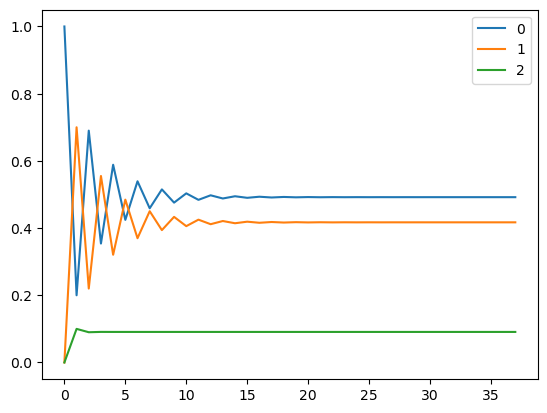

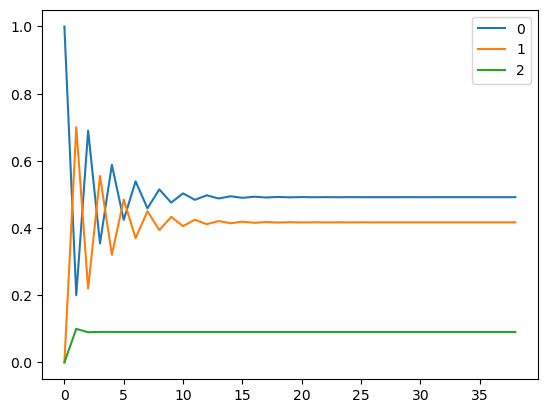

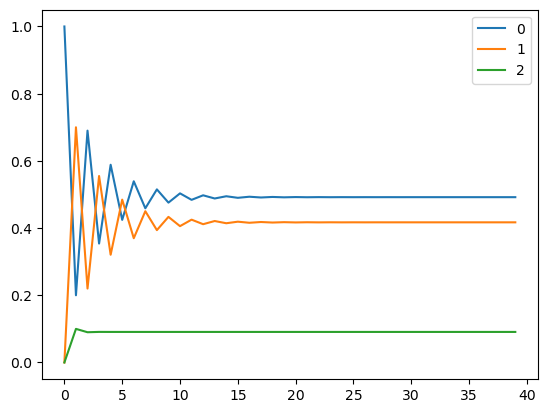

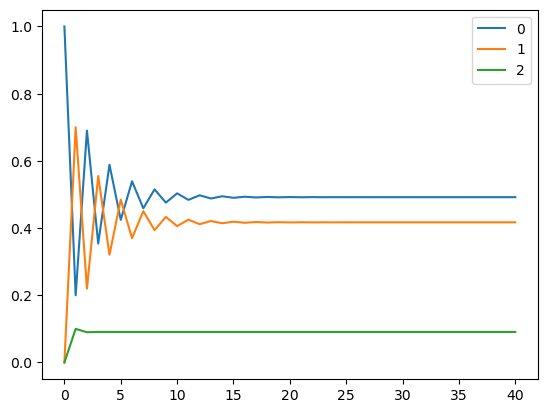

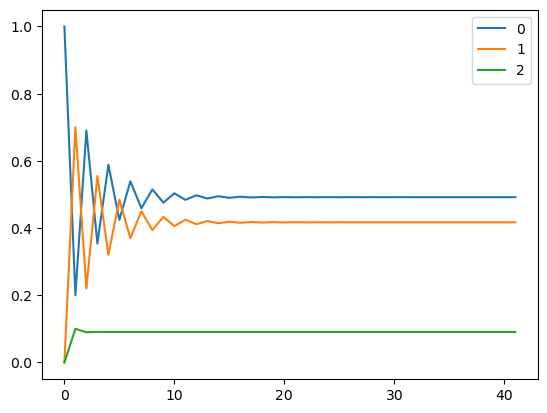

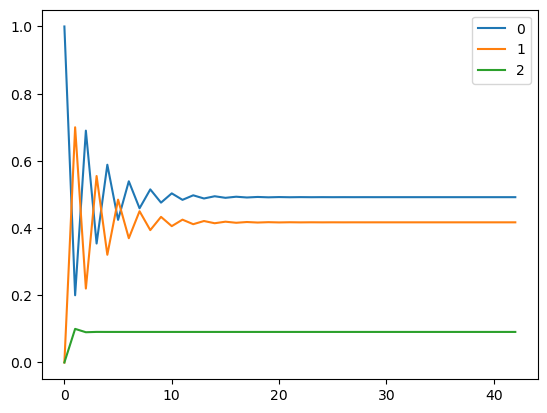

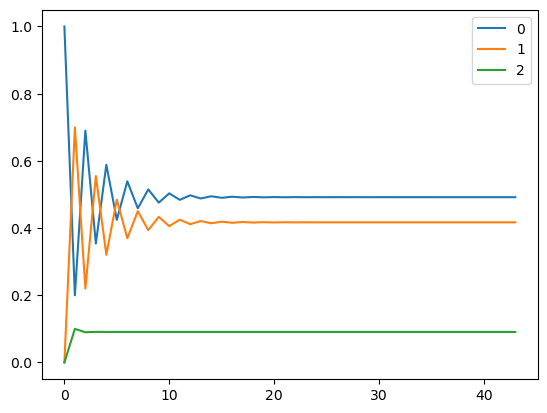

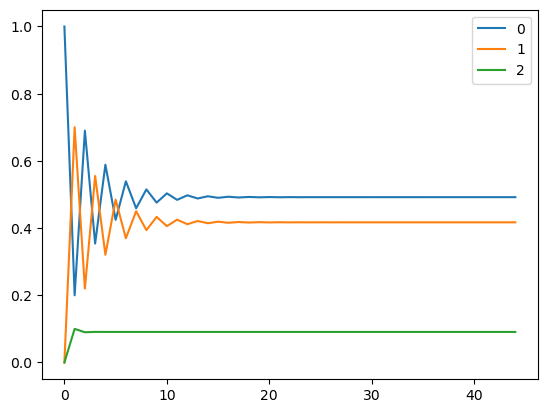

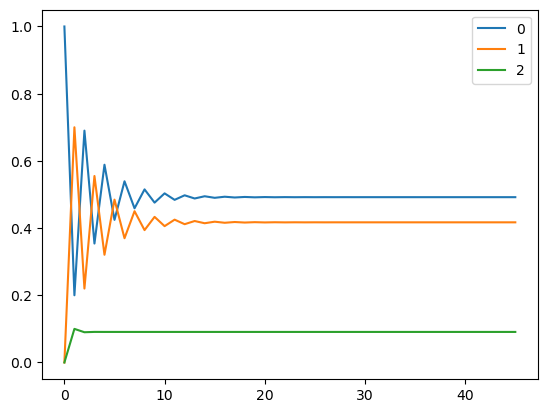

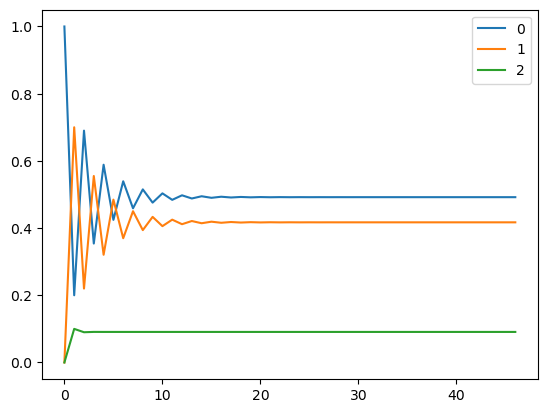

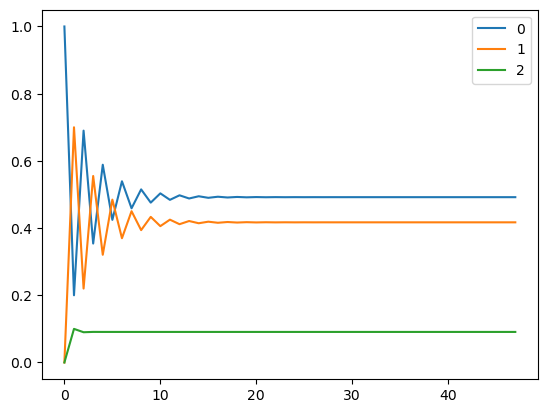

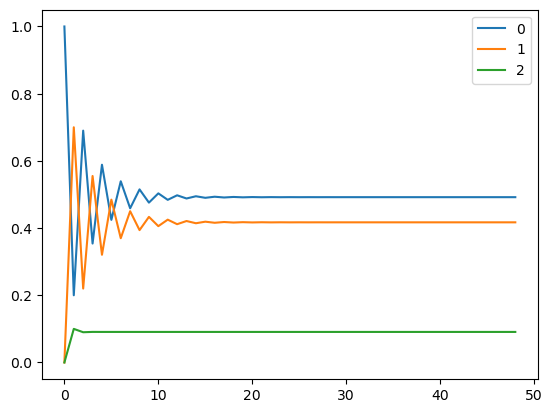

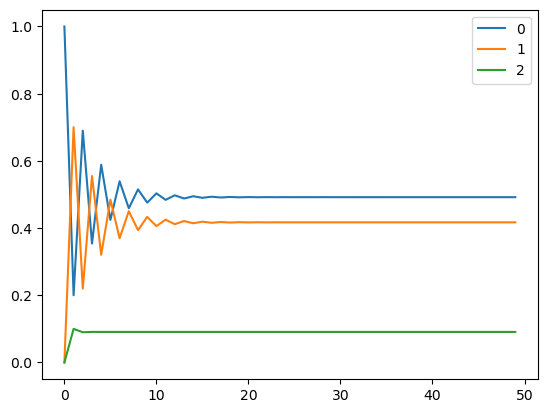

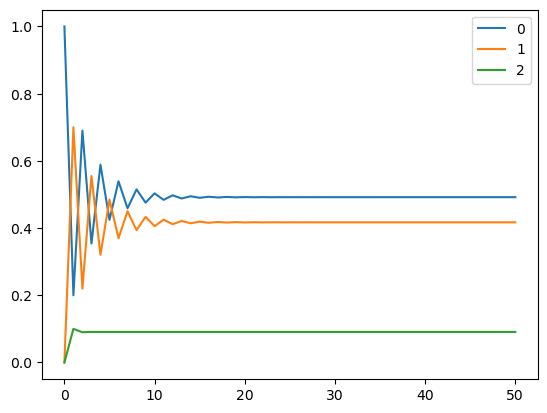

In [ ]:
import numpy as np
import pandas as pd
from random import seed
from random import random
import matplotlib.pyplot as plt
P = np.array([[0.2, 0.7, 0.1],
              [0.9, 0.0, 0.1],
              [0.2, 0.8, 0.0]])
state=np.array([[1.0, 0.0, 0.0]])
stateHist=state
dfStateHist=pd.DataFrame(state)
distr_hist = [[0,0,0]]
for x in range(50):
  state=np.dot(state,P)
  print(state)
  stateHist=np.append(stateHist,state,axis=0)
  dfDistrHist = pd.DataFrame(stateHist)
  dfDistrHist.plot()
plt.show()

The calculation converges to the stationary distribution quite quickly:

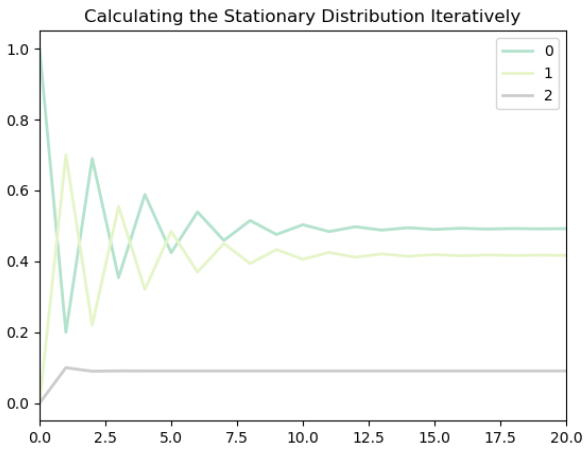

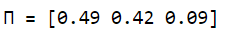

With Pi being the stationary distribution, as described earlier.

This may also be accomplished in this case with a linear algebra solution of a set of over-determined equations:

A=np.append(transpose(P)-identity(3),[[1,1,1]],axis=0

b=transpose(np.array([0,0,0,1]))

np.linalg.solve(transpose(A).dot(A), transpose(A).dot(b)

Which also returns [0.49, 0.42 , 0.09], the stationary distribution π.

How we got to this calculation is shown below:

It can be shown that a Markov chain is stationary with stationary distribution π if πP=π and π**i**=1

Where **i** is a unit column vector — i.e. the sum of the probabilities must be exactly 1, which may also be expressed as

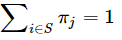

Doing some algebra:

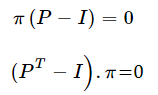

Combining with π**i**=1:

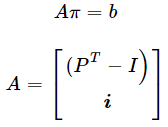

And **b** is a vector of which all elements except the last is 0.

Following from Rouché–Capelli,

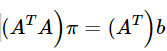

from which as can solve for Pi, the stationary distribution, provided that the augmented matrix [A|b] rank is equal to the rank of the coefficient matrix A.

Again, this algorithm implementation can be made generic, extended, and implemented as a class.

## Simulating from a Markov Chain

One can simulate from a Markov chain by noting that the collection of moves from any given state (the corresponding row in the probability matrix) form a multinomial distribution. One can thus simulate from a Markov Chain by simulating from a multinomial distribution.

One way to simulate from a multinomial distribution is to divide a line of length 1 into intervals proportional to the probabilities, and then picking an interval based on a uniform random number between 0 and 1.

See Wikipedia here https://en.wikipedia.org/wiki/Multinomial_distribution.

This is illustrated in the function simulate_multinomial below. We start with

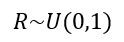

We then use cs, the cumulative sum of probabilities in P in order to proportionally distribute random numbers.

[[0.49050949 0.42757243 0.08191808]]
[[0.19387755 0.73061224 0.0755102 ]
 [0.89485981 0.         0.10514019]
 [0.14634146 0.85365854 0.        ]]


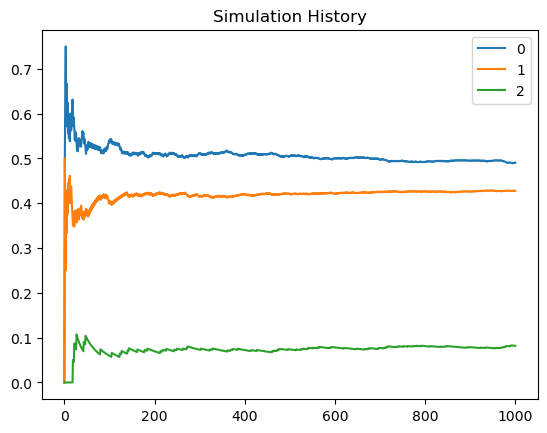

In [ ]:
import numpy as np
import pandas as pd
from random import seed
from random import random
import matplotlib.pyplot as plt
P = np.array([[0.2, 0.7, 0.1],
              [0.9, 0.0, 0.1],
              [0.2, 0.8, 0.0]])
stateChangeHist= np.array([[0.0,  0.0,  0.0],
                          [0.0, 0.0,  0.0],
                          [0.0, 0.0,  0.0]])
state=np.array([[1.0, 0.0, 0.0]])
currentState=0
stateHist=state
dfStateHist=pd.DataFrame(state)
distr_hist = [[0,0,0]]
seed(4)
# Simulate from multinomial distribution
def simulate_multinomial(vmultinomial):
  r=np.random.uniform(0.0, 1.0)
  CS=np.cumsum(vmultinomial)
  CS=np.insert(CS,0,0)
  m=(np.where(CS<r))[0]
  nextState=m[len(m)-1]
  return nextState
for x in range(1000):
  currentRow=np.ma.masked_values((P[currentState]), 0.0)
  nextState=simulate_multinomial(currentRow)
  # Keep track of state changes
  stateChangeHist[currentState,nextState]+=1
  # Keep track of the state vector itself
  state=np.array([[0,0,0]])
  state[0,nextState]=1.0
  # Keep track of state history
  stateHist=np.append(stateHist,state,axis=0)
  currentState=nextState
  # calculate the actual distribution over the 3 states so far
  totals=np.sum(stateHist,axis=0)
  gt=np.sum(totals)
  distrib=totals/gt
  distrib=np.reshape(distrib,(1,3))
  distr_hist=np.append(distr_hist,distrib,axis=0)
print(distrib)
P_hat=stateChangeHist/stateChangeHist.sum(axis=1)[:,None]
# Check estimated state transition probabilities based on history so far:
print(P_hat)
dfDistrHist = pd.DataFrame(distr_hist)
# Plot the distribution as the simulation progresses over time
dfDistrHist.plot(title="Simulation History")
plt.show()

From the graph, it can be seen that the distribution starts converging to the stationary distribution somewhere after around 400 simulation steps.

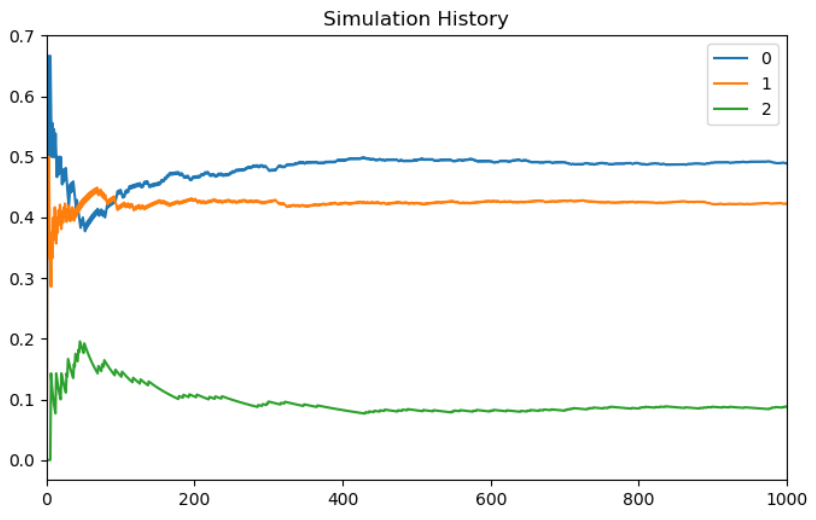

The distribution converges to [0.47652348 0.41758242 0.10589411]:


The distribution is quite close to the stationary distribution that we calculated by solving the Markov chain earlier. In fact, rounded to two decimals it is identical: [0.49, 0.42, 0.09].


As we can see below, reconstructing the state transition matrix from the transition history gives us the expected result:

[0.18, 0.72, 0.10]

[0.91, 0.00, 0.09]

[0.19, 0.80, 0.00]

This algorithm implementation can be made generic, extended, and implemented as a class.

It illustrates how compact and concise algorithm implementation can be achieved with Python.

## Application in Media, Telecommunications, or Similar Industry.

Let’s say, for a particular demographic, which aligns to high-value customers, we have 4 ‘competitors’ in a subscription media market (pay-TV, for example), with a relatively stable but changing distribution of [.55, 0.2, 0.1, 0.15], with the last group at 15% not having any particular subscription service, preferring to consume free content on demand.

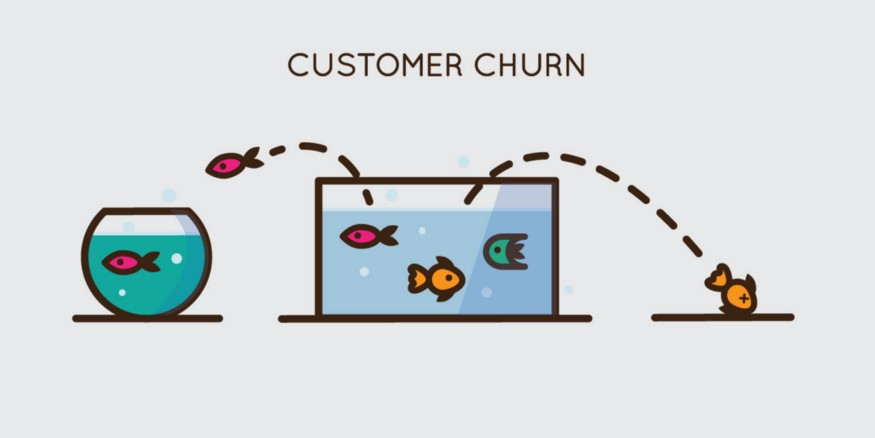

The second biggest competitor (b) has just launched a new premium product and the incumbent suspects that it is eroding their market share. They would like to know how it may ultimately impact their market share if they do not intervene. They would also like to understand their own internal churn dynamics, and how it relates to their market share.

Let’s assume they know they sometimes lose customers to their competitors, including free content, particularly as their high Average Revenue Per User (ARPU) customer base evolves, and that they sometimes gain customers, but they do not understand the full picture.

So, we imagine they commission us to do a study.

Here we make a lot of implicit assumptions of the dynamics of the demographic in question to keep things simple. For example, we assume the transition probabilities remain constant.

Firstly, we do a market survey to understand how consumers are moving between the different providers, and from there we can construct a probability matrix as follows:

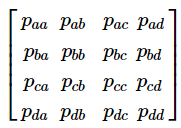

With a,b,c,d representing our market players.

The market research indicated produced the following estimated probabilities that a consumer would move from one service provider to another:

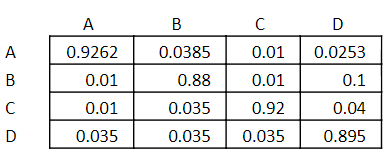

The first question we are interested in is what will happen if A keeps on losing customers to B at the estimated rate, taking into consideration all the other churn probabilities.

Using the matrix solution we derived earlier, and coding it in Python, we can calculate the new stationary distribution.

P = np.array([[0.9262, 0.0385, 0.01, 0.0253],
              [0.01, 0.94, 0.01, 0.04],
              [0.01, 0.035, 0.92, 0.04],
              [0.035, 0.035, 0.035, 0.895]])
              
A=np.append(transpose(P)-identity(4),[[1,1,1,1]],axis=0)

b=transpose(np.array([0,0,0,0,1]))

np.linalg.solve(transpose(A).dot(A), transpose(A).dot(b))

Which gives us the new stationary distribution [0.19, 0.37 , 0.18, 0.25]

However, when we check the rank of the coefficient matrix and the augmented matrix, we notice that, unlike the simpler example, they do not correspond. This means that the analytical problem formulation may not have a unique solution, so we want to check it with one of the other techniques.

np.linalg.matrix_rank(np.append(A,np.transpose(b.reshape(1,5)), axis=1))

5

np.linalg.matrix_rank(A)

4

It can be shown that the iterative solution (where we raise the transition matrix to the power of n) does not converge, which leaves us with the simulation option.

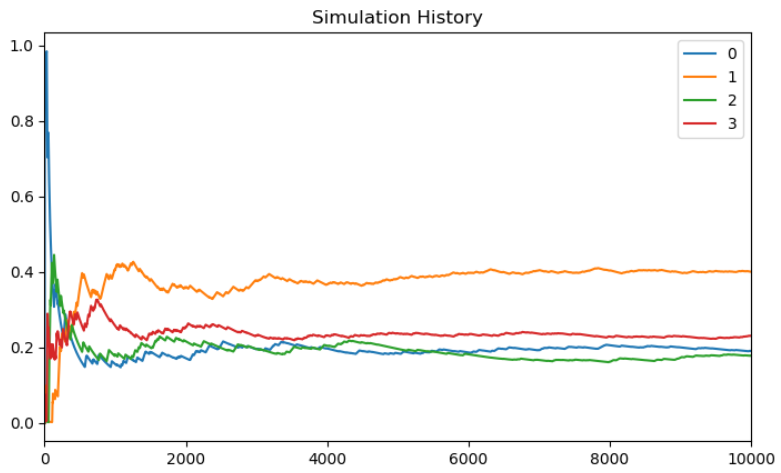

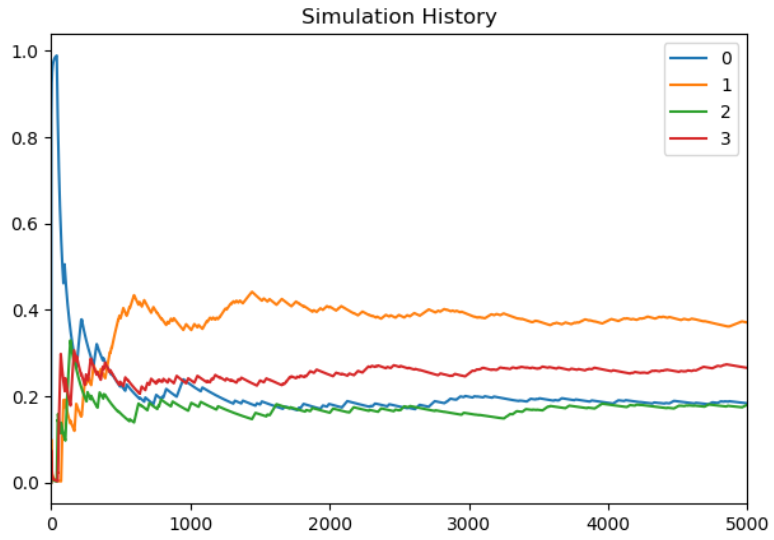

From the above, we can estimate that, in the long run, the stationary distribution will be something like this: [0.19, 0.4, 0.18, 0.23], which is actually very close to the analytical solution.

In other words, the market share of the incumbent can be expected to drop to around 20%, while the competitor will go up to around 40%.

From this, we can also see that the analytical and simulation solutions for the more complex problem, which is plausible in the real world, indeed still corresponds.

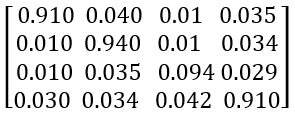

I hope you enjoyed this basic introduction on how discrete Markov Chains can be used to solve real-world problems and encourage you to think of questions in your own organization that can be answered in this way. You can also extend the example by calculating how valuable it would be to retain the churning customers, and thus how much it would be worth investing in retention.